# RAGAS Evaluation — Psychology RAG Chatbot

This notebook evaluates the Psychology RAG pipeline using the [RAGAS](https://docs.ragas.io) framework.

## Metrics computed
| Metric | What it measures |
|---|---|
| **Faithfulness** | Are all claims in the answer supported by the retrieved context? |
| **Answer Relevancy** | Is the answer relevant to the user question? |
| **Context Precision** | Are the top retrieved chunks actually the most relevant ones? |
| **Context Recall** | Does the retrieved context contain everying needed to answer? |

**Judge LLM:** Ollama `gemma3:4b` (local, no quota)  
**Test set:** 50 random Q&A pairs from `Psychology-10K.json` (ground truth = `output` field)

In [17]:
# Install dependencies if needed
# !pip install "ragas>=0.2.0" langchain-community langchain-ollama faiss-cpu sentence-transformers

In [34]:
# ── Cell 1: Imports & config ──────────────────────────────────────────────────
import json
import random
import sys
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
from pathlib import Path

import faiss
import numpy as np
import requests
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer

from datasets import Dataset
from ragas import evaluate
# Classic ragas.metrics (still supports LangchainLLMWrapper / local Ollama)
from ragas.metrics import (
    Faithfulness,
    AnswerRelevancy,
    ContextPrecision,
    ContextRecall,
)
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_ollama import ChatOllama
from langchain_community.embeddings import HuggingFaceEmbeddings

# ── CONFIG ────────────────────────────────────────────────────────────────────
DATASET_PATH     = Path('../Psychology/Psychology-10K.json')
CACHE_DIR        = Path('../Psychology/.rag_cache')
EMBEDDING_MODEL  = 'sentence-transformers/all-MiniLM-L6-v2'
OLLAMA_URL       = 'http://localhost:11434'
JUDGE_MODEL      = 'gemma3:4b'   # change to gemma3:270m for faster (less accurate) eval
RAG_MODEL        = 'gemma3:4b'
TOP_K            = 5
NUM_EVAL_SAMPLES = 50            # increase for more thorough (slower) evaluation
MAX_PROMPT_CHARS = 3000
RANDOM_SEED      = 42
OUTPUT_CSV       = Path('ragas_results.csv')
OUTPUT_PNG       = Path('ragas_results.png')

# Keep RAGAS judge contexts compact for stability with local LLMs
EVAL_CONTEXTS_PER_Q = 3
EVAL_CONTEXT_MAX_CHARS = 800

random.seed(RANDOM_SEED)
print('Config OK')
print('Dataset:', DATASET_PATH.resolve())
print('Cache  :', CACHE_DIR.resolve())

Config OK
Dataset: /home/vaishnavkoka/RE4BDD/Psychology/Psychology-10K.json
Cache  : /home/vaishnavkoka/RE4BDD/Psychology/.rag_cache


In [19]:
# ── Cell 2: Verify Ollama is reachable ───────────────────────────────────────
try:
    resp = requests.get(f'{OLLAMA_URL}/api/tags', timeout=5)
    models = [m['name'] for m in resp.json().get('models', [])]
    print('Ollama is running. Available models:')
    for m in models:
        print(' •', m)
    if not any(JUDGE_MODEL in m for m in models):
        print(f'\nWARNING: {JUDGE_MODEL} not found. Run: ollama pull {JUDGE_MODEL}')
    else:
        print(f'\nJudge model {JUDGE_MODEL} is ready ✓')
except Exception as e:
    print('ERROR: Ollama not reachable:', e)
    print('Start Ollama with: ollama serve')

Ollama is running. Available models:
 • deepseek-r1:7b
 • gemma3:270m
 • gemma3:4b

Judge model gemma3:4b is ready ✓


In [20]:
# ── Cell 3: Load dataset & build test set ────────────────────────────────────
with DATASET_PATH.open('r', encoding='utf-8') as f:
    full_data = json.load(f)

print(f'Full dataset: {len(full_data):,} records')

# Each record has: instruction, input, output
# question = instruction + input  |  ground_truth = output
samples = random.sample(full_data, NUM_EVAL_SAMPLES)

eval_questions    = []
eval_ground_truth = []

for item in samples:
    q = (item.get('instruction', '') + ' ' + item.get('input', '')).strip()
    a = item.get('output', '').strip()
    if q and a:
        eval_questions.append(q)
        eval_ground_truth.append(a)

print(f'Evaluation samples: {len(eval_questions)}')
print('\nSample question:', eval_questions[0][:120])
print('Ground truth   :', eval_ground_truth[0][:120])

Full dataset: 9,846 records
Evaluation samples: 50

Sample question: If you are a licensed psychologist, please provide this patient with a helpful response to their concern. I'm struggling
Ground truth   : Trust is an important component of any healthy relationship, but it can be difficult to rebuild once it's been broken. L


In [21]:
# ── Cell 4: Load embeddings + FAISS index (from existing cache) ───────────────
embedding_model = SentenceTransformer(EMBEDDING_MODEL)

emb_path  = CACHE_DIR / 'embeddings.npy'
idx_path  = CACHE_DIR / 'faiss.index'
meta_path = CACHE_DIR / 'meta.json'

if emb_path.exists() and idx_path.exists():
    chunks_embeddings = np.load(emb_path)
    index = faiss.read_index(str(idx_path))
    meta = json.loads(meta_path.read_text())
    chunk_size = meta.get('chunk_size', 350)
    print(f'Loaded cached FAISS index: {index.ntotal:,} vectors')
else:
    raise FileNotFoundError(
        f'No FAISS cache found at {CACHE_DIR}. '
        'Please run psychology_rag_powerful.ipynb first to build the index.'
    )

# Rebuild the chunks list (same logic as the chatbot)
def to_documents(records):
    docs = []
    for item in records:
        q = (item.get('instruction', '') + ' ' + item.get('input', '')).strip()
        a = item.get('output', '').strip()
        docs.append(f'Question: {q}\nAnswer: {a}')
    return docs

documents = to_documents(full_data)
chunks = []
for doc in documents:
    words = doc.split()
    for i in range(0, len(words), chunk_size):
        chunks.append(' '.join(words[i:i + chunk_size]))

print(f'Chunks rebuilt: {len(chunks):,}')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 15585.46it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded cached FAISS index: 9,846 vectors
Chunks rebuilt: 9,846


In [22]:
# ── Cell 5: Define retrieval + generation helpers ────────────────────────────

def retrieve_context(query: str, k: int = TOP_K) -> list[str]:
    """Return top-k relevant chunks for a query."""
    q_emb = embedding_model.encode([query], convert_to_numpy=True)
    _, idxs = index.search(q_emb.astype('float32'), k)
    return [chunks[i] for i in idxs[0]]


def build_prompt(question: str, context_chunks: list[str]) -> str:
    context = '\n\n---\n\n'.join(context_chunks[:3])[:MAX_PROMPT_CHARS]
    return (
        'You are a psychology counselor assistant. '
        'Answer concisely and empathetically based only on the context provided.\n\n'
        f'Context:\n{context}\n\n'
        f'Question: {question}\n\n'
        'Answer:'
    )


def generate_answer(question: str, context_chunks: list[str]) -> str:
    """Call Ollama to generate an answer given question + context."""
    prompt = build_prompt(question, context_chunks)
    payload = {
        'model': RAG_MODEL,
        'messages': [
            {'role': 'system', 'content': 'You are an empathetic mental health assistant. Be concise.'},
            {'role': 'user',   'content': prompt}
        ],
        'stream': False,
        'options': {'temperature': 0.3, 'num_predict': 200}
    }
    resp = requests.post(f'{OLLAMA_URL}/v1/chat/completions', json=payload, timeout=120)
    resp.raise_for_status()
    return (resp.json()['choices'][0]['message']['content'] or '').strip()


# Quick smoke test
test_ctx = retrieve_context(eval_questions[0])
test_ans = generate_answer(eval_questions[0], test_ctx)
print('Retrieval + generation smoke test OK')
print('Sample answer:', test_ans[:200])

Retrieval + generation smoke test OK
Sample answer: It takes courage to acknowledge this. Let’s understand what’s fueling these feelings and build a path toward more secure connections.


In [23]:
# ── Cell 6: Build RAGAS dataset ──────────────────────────────────────────────
# For each eval question: retrieve, generate, collect contexts
# This takes a few minutes (~1-2 min per 10 questions with gemma3:4b)

from tqdm.auto import tqdm

ragas_rows = []
errors = 0

for i, (question, ground_truth) in enumerate(tqdm(
    zip(eval_questions, eval_ground_truth),
    total=len(eval_questions),
    desc='Generating answers'
)):
    try:
        contexts = retrieve_context(question)
        answer   = generate_answer(question, contexts)
        ragas_rows.append({
            'user_input':    question,
            'response':      answer,
            'retrieved_contexts': contexts,
            'reference':     ground_truth,
        })
    except Exception as e:
        errors += 1
        print(f'[{i}] Error: {e}')

print(f'\nDone: {len(ragas_rows)} rows collected, {errors} errors')
ragas_dataset = Dataset.from_list(ragas_rows)
ragas_dataset

Generating answers: 100%|██████████| 50/50 [05:13<00:00,  6.28s/it]


Done: 50 rows collected, 0 errors


Dataset({
    features: ['user_input', 'response', 'retrieved_contexts', 'reference'],
    num_rows: 50
})

In [35]:
# ── Cell 7: Configure RAGAS judge LLM + embeddings ───────────────────────────
judge_llm = LangchainLLMWrapper(ChatOllama(
    model=JUDGE_MODEL,
    base_url=OLLAMA_URL,
    temperature=0,
))

# Use sentence-transformer embeddings for AnswerRelevancy.
# (Using a chat model as embedding backend leads to failed/NaN relevancy scores.)
judge_emb = LangchainEmbeddingsWrapper(HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL,
))

# Instantiate metrics with the local judge
faithfulness_metric     = Faithfulness(llm=judge_llm)
answer_relevancy_metric = AnswerRelevancy(llm=judge_llm, embeddings=judge_emb)
ctx_precision_metric    = ContextPrecision(llm=judge_llm)
ctx_recall_metric       = ContextRecall(llm=judge_llm)

metrics = [
    faithfulness_metric,
    answer_relevancy_metric,
    ctx_precision_metric,
    ctx_recall_metric,
]

print('Judge LLM:', JUDGE_MODEL)
print('Judge embeddings:', EMBEDDING_MODEL)
print('Metrics  :', [m.__class__.__name__ for m in metrics])

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12660.84it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Judge LLM: gemma3:4b
Judge embeddings: sentence-transformers/all-MiniLM-L6-v2
Metrics  : ['Faithfulness', 'AnswerRelevancy', 'ContextPrecision', 'ContextRecall']


In [36]:
# ── Cell 8: Run RAGAS evaluation ─────────────────────────────────────────────
# This calls the judge LLM for each row × each metric → takes several minutes.
import warnings
warnings.filterwarnings('ignore')

print(f'Running RAGAS evaluation on {len(ragas_dataset)} samples...')
print(f'Judge: {JUDGE_MODEL} | Metrics: {len(metrics)}')
print('(This may take 5-15 minutes depending on model speed)\n')

# Trim contexts before judging to reduce parser failures/timeouts on local LLMs
def _trim_contexts(ctxs):
    if not isinstance(ctxs, list):
        return [str(ctxs)[:EVAL_CONTEXT_MAX_CHARS]]
    return [str(c)[:EVAL_CONTEXT_MAX_CHARS] for c in ctxs[:EVAL_CONTEXTS_PER_Q]]

eval_rows = []
for row in ragas_dataset:
    eval_rows.append({
        'user_input': row['user_input'],
        'response': row['response'],
        'retrieved_contexts': _trim_contexts(row['retrieved_contexts']),
        'reference': row['reference'],
    })

eval_dataset = Dataset.from_list(eval_rows)

results = evaluate(
    dataset=eval_dataset,
    metrics=metrics,
    batch_size=1,
)

print('\nEvaluation complete!')
print(results)

Running RAGAS evaluation on 50 samples...
Judge: gemma3:4b | Metrics: 4
(This may take 5-15 minutes depending on model speed)



Evaluating: 100%|██████████| 200/200 [2:18:36<00:00, 41.58s/it]  



Evaluation complete!
{'faithfulness': 0.7110, 'answer_relevancy': 0.0519, 'context_precision': 0.6867, 'context_recall': 0.8850}


In [41]:
# ── Cell 9: Display & save results ───────────────────────────────────────────

# Per-metric summary scores (robust to list/array/scalar outputs)
def _metric_mean(value):
    if isinstance(value, (list, tuple, np.ndarray, pd.Series)):
        arr = pd.to_numeric(pd.Series(value), errors='coerce').dropna()
        return float(arr.mean()) if len(arr) else float('nan')
    return float(value)

summary = {
    'faithfulness':      _metric_mean(results['faithfulness']),
    'answer_relevancy':  _metric_mean(results['answer_relevancy']),
    'context_precision': _metric_mean(results['context_precision']),
    'context_recall':    _metric_mean(results['context_recall']),
}

summary_df = pd.DataFrame([
    {
        'Metric': k.replace('_', ' ').title(),
        'Score': round(v, 4) if pd.notna(v) else np.nan,
        'Score%': f'{v*100:.1f}%' if pd.notna(v) else 'NaN',
    }
    for k, v in summary.items()
])

print('\n=== RAGAS Summary Scores ===')
print(summary_df.to_string(index=False))

# Per-row detailed results
df = results.to_pandas()
print(f'\nFull per-row results shape: {df.shape}')

# Save both
df.to_csv(OUTPUT_CSV, index=False)
summary_df.to_csv(OUTPUT_CSV.with_name('ragas_summary.csv'), index=False)
print(f'\nSaved detailed results -> {OUTPUT_CSV}')
print('Saved summary         -> ragas_summary.csv')


=== RAGAS Summary Scores ===
           Metric  Score Score%
     Faithfulness 0.7110  71.1%
 Answer Relevancy 0.0519   5.2%
Context Precision 0.6867  68.7%
   Context Recall 0.8850  88.5%

Full per-row results shape: (50, 8)

Saved detailed results -> ragas_results.csv
Saved summary         -> ragas_summary.csv


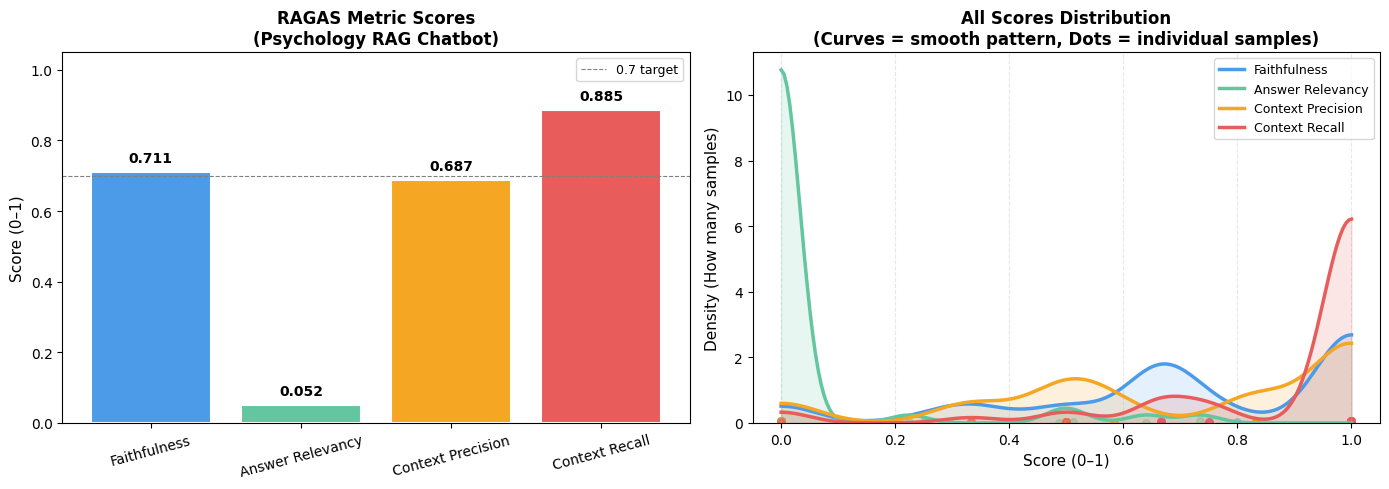

Plot saved → ragas_results.png


In [45]:
# ── Cell 10: Visualise results ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Bar chart: summary scores ---
ax = axes[0]
colors = ['#4C9BE8', '#63C6A0', '#F5A623', '#E85C5C']
bars = ax.bar(summary_df['Metric'], summary_df['Score'], color=colors, edgecolor='white', linewidth=1.5)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score (0–1)', fontsize=11)
ax.set_title('RAGAS Metric Scores\n(Psychology RAG Chatbot)', fontsize=12, fontweight='bold')
ax.axhline(0.7, color='gray', linestyle='--', linewidth=0.8, label='0.7 target')
ax.legend(fontsize=9)
for bar, score in zip(bars, summary_df['Score']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{score:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.tick_params(axis='x', labelrotation=15)

# --- Density plot (smooth curves): distribution per metric ---
ax2 = axes[1]
metric_cols = [c for c in df.columns if c in
               ['faithfulness', 'answer_relevancy', 'context_precision', 'context_recall']]

# Plot each metric as a smooth density curve + individual sample dots
for col, color in zip(metric_cols, colors):
    data = df[col].dropna().values
    # Density curve (KDE = kernel density estimation)
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(data, bw_method=0.2)
    x_range = np.linspace(0, 1, 200)
    density = kde(x_range)
    ax2.plot(x_range, density, linewidth=2.5, label=col.replace('_', ' ').title(), color=color)
    ax2.fill_between(x_range, density, alpha=0.15, color=color)
    
    # Add individual sample points on x-axis (jittered for visibility)
    jitter = np.random.normal(0, 0.02, len(data))
    ax2.scatter(data, jitter + 0.02, alpha=0.4, s=30, color=color)

ax2.set_xlabel('Score (0–1)', fontsize=11)
ax2.set_ylabel('Density (How many samples)', fontsize=11)
ax2.set_title('All Scores Distribution\n(Curves = smooth pattern, Dots = individual samples)', fontsize=12, fontweight='bold')
ax2.set_xlim(-0.05, 1.05)
ax2.set_ylim(0, ax2.get_ylim()[1])
ax2.legend(fontsize=9, loc='upper right')
ax2.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved → {OUTPUT_PNG}')

In [43]:
# ── Cell 11: Inspect worst-performing samples ────────────────────────────────
# Helps identify where the RAG pipeline struggles

print('=== Lowest Faithfulness Samples ===')
worst = df.nsmallest(5, 'faithfulness')[['user_input', 'response', 'faithfulness']]
for _, row in worst.iterrows():
    print(f'  Score: {row["faithfulness"]:.3f}')
    print(f'  Q: {str(row["user_input"])[:100]}')
    print(f'  A: {str(row["response"])[:120]}')
    print()

print('=== Lowest Context Recall Samples ===')
worst_recall = df.nsmallest(5, 'context_recall')[['user_input', 'context_recall']]
for _, row in worst_recall.iterrows():
    print(f'  Score: {row["context_recall"]:.3f}')
    print(f'  Q: {str(row["user_input"])[:100]}')
    print()

=== Lowest Faithfulness Samples ===
  Score: 0.000
  Q: If you are a licensed psychologist, please provide this patient with a helpful response to their con
  A: It’s completely understandable to feel nervous before a big interview. Let’s talk about what’s triggering those feelings

  Score: 0.000
  Q: If you are a licensed psychologist, please provide this patient with a helpful response to their con
  A: It takes courage to recognize this challenge. Let’s explore what’s getting in the way and find some strategies to help y

  Score: 0.000
  Q: If you are a licensed psychologist, please provide this patient with a helpful response to their con
  A: It takes courage to acknowledge this. We can explore what makes vulnerability feel difficult and build strategies for co

  Score: 0.000
  Q: If you are a licensed psychologist, please provide this patient with a helpful response to their con
  A: That sounds incredibly difficult. It’s understandable to feel this way when the cause isn’t cl